<a href="https://colab.research.google.com/github/tonyyucrachurata-dev/el-buen-sabor-mvp/blob/main/TRABAJO_FINAL_IA_DATAEXPERT_YUCRA_TONY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PASO 1: CARGA Y EXPLORACIÓN DE DATOS

# Instalamos la herramienta para descargar desde Kaggle

In [1]:
!pip install kagglehub

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

# Descargamos el dataset de la NASA (Exoplanetas)
# Este dataset es ideal para modelos de clasificación

In [5]:
path = kagglehub.dataset_download("kanchana1990/nasa-exoplanet-archive-intelligence")
# Localizamos el archivo CSV y lo cargamos con Pandas
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
df_exo = pd.read_csv(os.path.join(path, csv_file))

Using Colab cache for faster access to the 'nasa-exoplanet-archive-intelligence' dataset.


# Visualización inicial de los datos

In [6]:
print("--- PRIMERAS 5 FILAS DEL DATASET ---")
display(df_exo.head())

print("\n--- INFORMACIÓN DE COLUMNAS Y TIPOS DE DATOS ---")
df_exo.info()

print("\n--- RESUMEN ESTADÍSTICO INICIAL ---")
display(df_exo.describe())

--- PRIMERAS 5 FILAS DEL DATASET ---


,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,Kepler-1167 b,Kepler-1167,1,1,Transit,2016.0,Kepler,1.003934,1.710000,3.570,...,298.302660,47.693965,0,Super-Earth,False,False,False,Far(500-2kpc),K-type,Short(1-10d)
1,Kepler-1740 b,Kepler-1740,1,1,Transit,2021.0,Kepler,8.172400,3.323214,11.000,...,293.873663,38.922455,0,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
2,Kepler-1581 b,Kepler-1581,1,1,Transit,2016.0,Kepler,6.283855,0.800000,0.437,...,287.371320,39.603623,0,Sub-Earth,False,False,False,Mid(100-500pc),F-type,Short(1-10d)
3,Kepler-644 b,Kepler-644,1,1,Transit,2016.0,Kepler,3.173917,3.150000,10.100,...,295.475702,43.493112,0,Mini-Neptune,False,False,False,Far(500-2kpc),F-type,Short(1-10d)
4,Kepler-1752 b,Kepler-1752,1,1,Transit,2021.0,Kepler,56.358501,4.540605,18.700,...,290.854140,51.222743,0,Neptune-like,False,False,True,Far(500-2kpc),G-type(Sun-like),Medium(10-100d)



--- INFORMACIÓN DE COLUMNAS Y TIPOS DE DATOS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6150 entries, 0 to 6149
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   planet_name           6150 non-null   object 
 1   host_star             6150 non-null   object 
 2   n_stars               6150 non-null   int64  
 3   n_planets             6150 non-null   int64  
 4   discovery_method      6150 non-null   object 
 5   disc_year             6149 non-null   float64
 6   disc_facility         6150 non-null   object 
 7   orbital_period_days   5816 non-null   float64
 8   planet_radius_earth   6100 non-null   float64
 9   planet_mass_earth     6119 non-null   float64
 10  equilibrium_temp_k    4587 non-null   float64
 11  orbital_eccentricity  5212 non-null   float64
 12  semi_major_axis_au    5834 non-null   float64
 13  star_temp_k           5860 non-null   float64
 14  star_radius_sun       

,n_stars,n_planets,disc_year,orbital_period_days,planet_radius_earth,planet_mass_earth,equilibrium_temp_k,orbital_eccentricity,semi_major_axis_au,star_temp_k,star_radius_sun,star_mass_sun,star_age_gyr,star_surface_gravity,star_metallicity,dist_from_earth_pc,star_vmag,ra,dec,controversial_flag
count,6150.000000,6150.000000,6149.000000,5.816000e+03,6100.000000,6119.000000,4587.000000,5212.000000,5834.000000,5860.000000,5836.000000,6142.000000,4839.000000,5832.000000,5600.000000,6123.000000,5855.000000,6150.000000,6150.000000,6150.000000
mean,1.103740,1.774309,2016.986339,7.359421e+04,5.841983,406.787994,912.895472,0.079236,15.718494,5398.163985,1.503790,0.936813,4.383390,4.384138,0.015630,711.669811,12.546162,232.888731,18.049038,0.007967
std,0.343093,1.158362,4.964920,5.273718e+06,5.436387,1142.866060,464.271129,0.152881,349.043858,1747.460059,3.950248,0.409758,3.001037,0.441306,0.188338,1212.136251,3.062720,91.676467,37.074883,0.088912
min,1.000000,1.000000,1992.000000,9.070629e-02,0.309800,0.020000,34.000000,0.000000,0.004400,415.000000,0.011500,0.009400,0.000000,0.541000,-1.000000,1.301190,0.872000,0.185606,-88.121111,0.000000
25%,1.000000,1.000000,2014.000000,4.347374e+00,1.820750,4.190000,566.000000,0.000000,0.052300,4904.750000,0.770000,0.770000,2.340000,4.292000,-0.080000,100.855000,10.611000,173.284640,-11.166116,0.000000
50%,1.000000,1.000000,2016.000000,1.112522e+01,2.840000,9.270000,818.000000,0.000000,0.102015,5546.000000,0.951690,0.940000,3.980000,4.453000,0.020000,376.658000,13.236000,284.914973,39.127119,0.000000
75%,1.000000,2.000000,2021.000000,3.976274e+01,11.990000,190.849000,1164.000000,0.091000,0.307750,5900.000000,1.250000,1.089500,5.665000,4.580000,0.130000,835.808000,14.943000,293.226852,45.384217,0.000000
max,4.000000,8.000000,2026.000000,4.020000e+08,87.205870,9534.852210,4050.000000,0.950000,19000.000000,57000.000000,88.475000,10.940000,16.100000,8.070000,0.600000,8500.000000,44.610000,359.974984,86.860343,1.000000


# PASO 2: VISUALIZACIÓN Y PREPROCESAMIENTO

In [7]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# 1. VISUALIZACIÓN

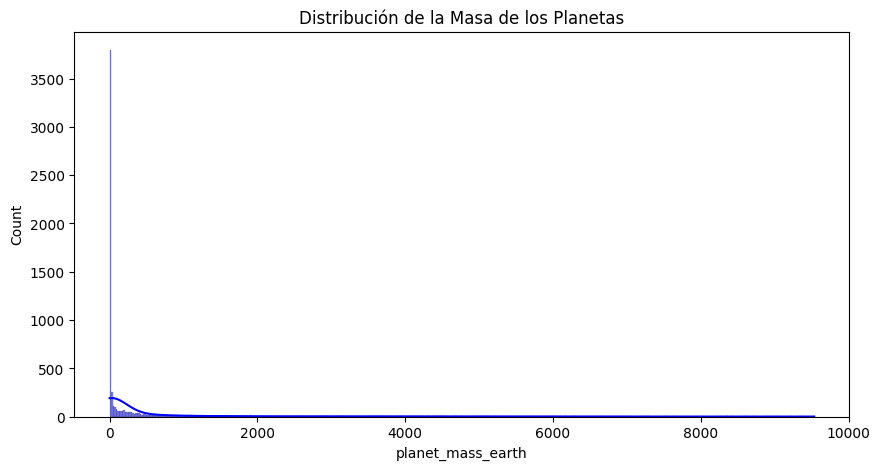

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df_exo['planet_mass_earth'].dropna(), kde=True, color='blue')
plt.title("Distribución de la Masa de los Planetas")
plt.show()

# 2. SELECCIÓN AUTOMÁTICA DE COLUMNAS (Para evitar el KeyError)
# Seleccionamos solo las columnas que son números (int o float)

In [9]:
X = df_exo.select_dtypes(include=['float64', 'int64']).dropna(axis=1, how='all') # Quitamos columnas vacías
X = X.dropna() # Quitamos filas con nulos

# Ajustamos las etiquetas (la respuesta que queremos predecir)

In [10]:
y = df_exo.loc[X.index, 'planet_type']

# 3. NORMALIZACIÓN Y DIVISIÓN
# Codificamos los nombres de planetas a números

In [11]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Dividimos en Entrenamiento (80%) y Prueba (20%)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Aplicamos StandardScaler

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- Preprocesamiento Completado sin errores ---")
print(f"Columnas usadas para el modelo: {list(X.columns)}")
print(f"Total de registros limpios: {len(X_train_scaled) + len(X_test_scaled)}")

--- Preprocesamiento Completado sin errores ---
Columnas usadas para el modelo: ['n_stars', 'n_planets', 'disc_year', 'orbital_period_days', 'planet_radius_earth', 'planet_mass_earth', 'equilibrium_temp_k', 'orbital_eccentricity', 'semi_major_axis_au', 'star_temp_k', 'star_radius_sun', 'star_mass_sun', 'star_age_gyr', 'star_surface_gravity', 'star_metallicity', 'dist_from_earth_pc', 'star_vmag', 'ra', 'dec', 'controversial_flag']
Total de registros limpios: 3806


# PASO 3: ENTRENAMIENTO Y EVALUACIÓN DEL MODELO

In [14]:
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

# 1. DEFINICIÓN DEL MODELO (Red Neuronal)
# Creamos una estructura de capas para que la IA aprenda

In [15]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(len(np.unique(y_encoded)), activation='softmax') # Capa de salida
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# 2. COMPILACIÓN

In [16]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 3. ENTRENAMIENTO

In [17]:
print("Entrenando el modelo")
history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, verbose=0, validation_split=0.1)

Entrenando el modelo


# 4. EVALUACIÓN Y PREDICCIÓN

In [18]:
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n--- Resultados del Modelo ---")
print(f"Precisión (Accuracy): {accuracy:.2f}")


--- Resultados del Modelo ---
Precisión (Accuracy): 0.92


# Generamos la Matriz de Confusión para el informe

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


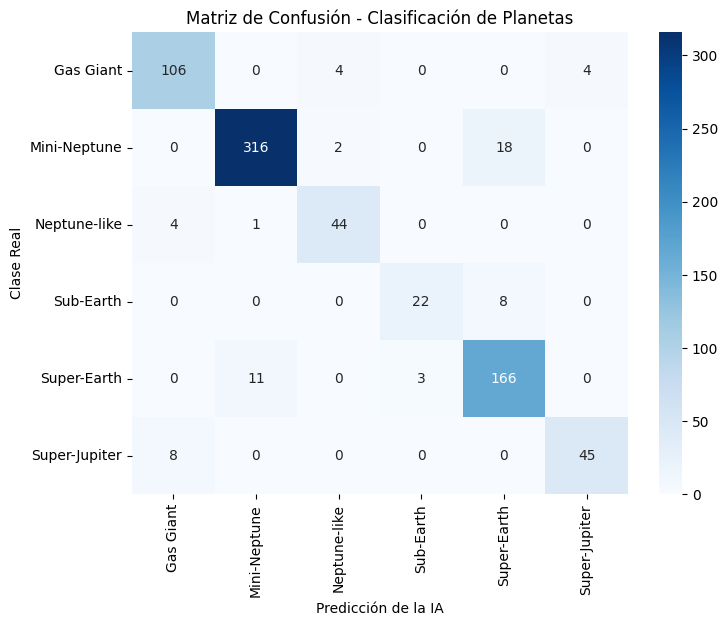

In [19]:
y_pred = np.argmax(model.predict(X_test_scaled), axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Matriz de Confusión - Clasificación de Planetas")
plt.xlabel("Predicción de la IA")
plt.ylabel("Clase Real")
plt.show()

# PASO 4: EJERCICIOS AUXILIARES (FUNDAMENTO MATEMÁTICO)

In [20]:
print("1.ESTADÍSTICA DESCRIPTIVA")
# Cálculo de Media y Mediana [cite: 39, 157]
col_est = 'planet_mass_earth'
media = df_exo[col_est].mean()
mediana = df_exo[col_est].median()
print(f"Variable analizada: {col_est}")
print(f"Media (Promedio): {media:.2f}")
print(f"Mediana (Punto medio): {mediana:.2f}")

1.ESTADÍSTICA DESCRIPTIVA
Variable analizada: planet_mass_earth
Media (Promedio): 406.79
Mediana (Punto medio): 9.27


# Identificación de valores atípicos (Outliers) usando Desviación Estándar

In [21]:
std_dev = df_exo[col_est].std()
limite_superior = media + (3 * std_dev)
limite_inferior = media - (3 * std_dev)
outliers = df_exo[(df_exo[col_est] > limite_superior) | (df_exo[col_est] < limite_inferior)]
print(f"\nSe encontraron {len(outliers)} valores atípicos (fuera de 3 desviaciones estándar).")
print("\n-2.ÁLGEBRA LINEAL CON NUMPY")


Se encontraron 171 valores atípicos (fuera de 3 desviaciones estándar).

-2.ÁLGEBRA LINEAL CON NUMPY


# Operaciones con vectores: Producto punto y Norma

In [23]:
v1 = np.array([1, 2, 3])
v2 = np.array([4, 5, 6])
prod_punto = np.dot(v1, v2)
norma_v1 = np.linalg.norm(v1)
print(f"Vector 1: {v1} | Vector 2: {v2}")
print(f"Producto Punto: {prod_punto}")
print(f"Norma Euclidiana de Vector 1: {norma_v1:.2f}")

Vector 1: [1 2 3] | Vector 2: [4 5 6]
Producto Punto: 32
Norma Euclidiana de Vector 1: 3.74


# Resolución de un sistema de ecuaciones lineales
# Sistema: 2x + y = 5  |  x - 3y = -1

In [24]:
A = np.array([[2, 1], [1, -3]])
B = np.array([5, -1])
solucion = np.linalg.solve(A, B)

print(f"\nResolución del sistema 2x + y = 5 y x - 3y = -1:")
print(f"Resultado: x = {solucion[0]:.2f}, y = {solucion[1]:.2f}")


Resolución del sistema 2x + y = 5 y x - 3y = -1:
Resultado: x = 2.00, y = 1.00
